# Multi-fidelity optimization

This page demonstrates how to minimize multi-fidelity problems. The purpose of multi-fidelity optimization is to use cheaper approximations to reduce the budget required for convergence.

This page assumes that the user is already familiar with unconstrained and constrained optimization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim import minimize

# utility method to help with plotting 2d functions
from smt_optim.utils.plot_2d import get_plot2d_data

## Unconstrained multi-fidelity optimization

The following example illustrates how to optimize the Sasena 2002 multi-fidelity test function. The problem is defined by a high-fidelity (true) function, and a low-fidelity function which will be used as an approximation. Both functions can be expressed mathematically as:

$$
\begin{aligned}
f_{\mathrm{HF}}(x) &= -\sin(x) - \exp\!\left(\frac{x}{100}\right) + 10, \\
f_{\mathrm{LF}}(x) &= f_{\mathrm{HF}}(x) + 0.3 + 0.03\,(x - 3)^2, \\
\end{aligned}
$$

The objective will be to minimize the high-fidelity function with respect to a bounded domain. It can be expressed as:

$$
\min_{x\in \mathbb R^1} f_\text{HF}(x) \quad \text{s.t.} \quad 0 \leq x \leq 10.
$$

The cell below defines the low- and high-fidelity objective functions that should be minimized.


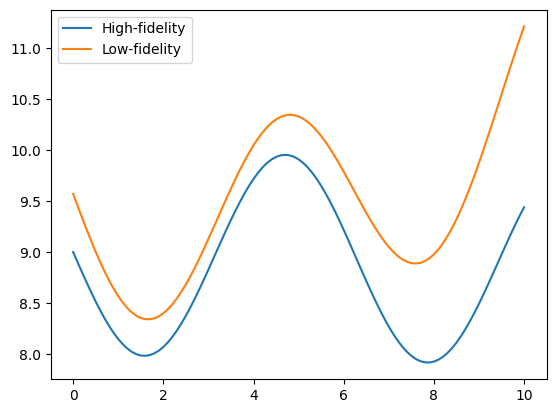

In [2]:
# high-fidelity function
def sasena2002_hf(x):
    return -np.sin(x)-np.exp(x/100)+10

# low-fidelity function
def sasena2002_lf(x):
    return sasena2002_hf(x)+0.3+0.03*(x-3)**2

bounds = np.array([
    [0, 10]
])

x_valid = np.linspace(bounds[0, 0], bounds[0, 1], 101)
y_hf = sasena2002_hf(x_valid)
y_lf = sasena2002_lf(x_valid)

fig, ax = plt.subplots()
ax.plot(x_valid, y_hf, label="High-fidelity")
ax.plot(x_valid, y_lf, label="Low-fidelity")
ax.legend()
plt.show()

### Starting the optimization

This example uses the `minimize` method to initiate the multi-fidelity Bayesian optimization. When dealing with multi-fidelity optimization, two arguments must be passed:

- `objective`: the function to minimize;
- `design_space`: the function boundary;
- `costs`: the sampling cost of each fidelity level.

<div class="admonition note"> <p class="admonition-title">Note</p>
    <p>The objective argument requires a list of callables. These callables and their associated sampling costs must be ordered by level of fidelity, from lowest to highest.<p>
</div>

Moreover, we can also pass the following optional arguments:

- `max_iter`: the maximum number of iterations before the program stops;
- `driver_kwargs`: kwargs to pass to the optimization driver. The `nt_init` parameter sets the number of high-fidelity samples should be in the initial DoE. In our case, `nt_init` is set to three samples. The `seed` parameter makes this example reproducible.

<div class="admonition note"> <p class="admonition-title">Note</p>
    <p>The initial multi-fidelity DoE is generated using SMT's <a href="https://smt.readthedocs.io/en/latest/_src_docs/applications/mfk.html">Nested Latin Hypercube Sampling</a>, meaning it will have the following properties: </p>
    <ul>
        <li> Samples will be nested;
        <li> Each lower-fidelity level will have twice as many samples as the next higher-fidelity level.
    </ul>
</div>

The minimize method returns a `State` object that contains the design of experiment (DoE) with all the low- and high-function samples. Using these samples, we can identify the best sampled function value found during the optimization process.


In [3]:
state = minimize(
    [sasena2002_lf, sasena2002_hf],     # in increasing order of fidelity
    bounds,
    costs=[0.2, 1.],                    # in increasing order of fidelity
    max_iter=10,
    driver_kwargs={
        "nt_init": 3,                   # number of sample in the initial Design of Experiment (DoE)
        "seed": 0,                      # makes this example reproducible
    }
)

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1          4.400    8.07060e+00      0.000e+00              1          0.134          0.160
             2          4.600    8.07060e+00      0.000e+00              1          0.118          0.151
             3          5.800    7.98975e+00      0.000e+00              2          0.111          0.165
             4          6.000    7.98975e+00      0.000e+00              1          0.223          0.312
             5          6.200    7.98975e+00      0.000e+00              1          0.211          0.263
             6          7.400    7.91824e+00      0.000e+00              2          0.198          0.288
             7          8.600    7.91824e+00      0.000e+00              2          0.167          0.266
             8          9.800    7.91824e+00      0.000e+00              2          0.177          0.297
             9         11.000    7.91824e+00      0.000

The `get_best_sample` class method accepts a `fidelity` argument that specifies the level from which to retrieve the best sample. By default, it fetches the best sample from the highest fidelity level.


In [4]:
print("####### Best low-fidelity sample #######")
best_sample = state.get_best_sample(fidelity=0)
print(best_sample)

print("####### Best high-fidelity sample #######")
best_sample = state.get_best_sample()
print(best_sample)

####### Best low-fidelity sample #######
======= sample data =======
x =             [1.68378209]
obj =           [8.34136862]
cstr =          []
eval_time =     [1.25820006e-05]
------- meta data -------
iter =     2
budget =     4.6000000000000005
fidelity =     0
rscv =     0.0

####### Best high-fidelity sample #######
======= sample data =======
x =             [7.86479479]
obj =           [7.91823506]
cstr =          []
eval_time =     [3.51500057e-06]
------- meta data -------
iter =     8
budget =     9.8
fidelity =     1
rscv =     0.0



### Plotting the results

The code snippet below exports all the evaluated low- and high-fidelity design points, as well as their corresponding objective values. It plots these values against their respective fidelity functions. The best sample is marked with a star.

When exporting the dataset using the export_as_dict class method, use the `fidelity` array to distinguish between different fidelity levels, as demonstrated below.


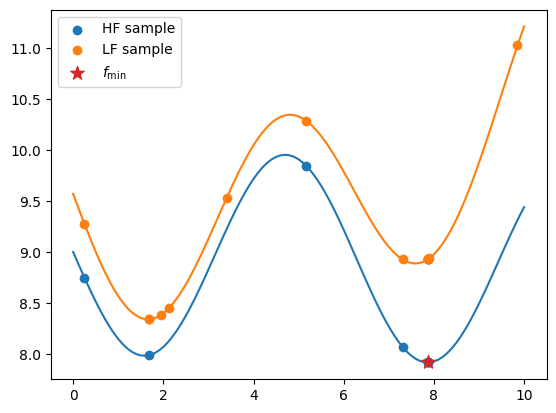

In [5]:
data = state.dataset.export_as_dict()

# retrieves the fidelity ID of each sample
fidelity = data["fidelity"]

# retrieves the low fidelity DoE
x_doe_lf = data["x"][fidelity == 0]
y_doe_lf = data["obj"][fidelity == 0]

# retrieve the high fidelity DoE
x_doe_hf = data["x"][fidelity == 1]
y_doe_hf = data["obj"][fidelity == 1]


fig, ax = plt.subplots()
# plots the HF function and samples
ax.plot(x_valid, y_hf)
ax.scatter(x_doe_hf, y_doe_hf, label="HF sample", color="C0")

# plots the LF function and samples
ax.plot(x_valid, y_lf)
ax.scatter(x_doe_lf, y_doe_lf, label="LF sample", color="C1")

# plots the best (HF) sample
ax.scatter(best_sample.x, best_sample.obj, label=r"$f_\min$", marker="*", color="C3", s=100, zorder=50)

ax.legend()
plt.show()


## Constrained multi-fidelity optimization

The following example demonstrates how to minimize the multi-fidelity constrained Rosenbrock test problem. The high- and low fidelity objective and constraint functions are as follows:

$$
\begin{aligned}
f_{\mathrm{HF}}(x_1, x_2) &= (1 - x_1)^2 + 100\,(x_2 - x_1^2)^2, \\
f_{\mathrm{LF}}(x_1, x_2) &= f_{\mathrm{HF}}(x_1, x_2) + 0.1\,\sin(10x_1 + 5x_2), \\
g_{\mathrm{HF}}(x_1, x_2) &= x_1^2 + \sqrt{x_2 - 1}, \\
g_{\mathrm{LF}}(x_1, x_2) &= g_{\mathrm{HF}}(x_1, x_2) - 0.1\,\sin(10x_1 + 5x_2).
\end{aligned}
$$

The objective will be to minimize the high fidelity objective function with respect to the high-fidelity inequality constraint:

$$
\begin{aligned}
\min_{x\in \mathbb R^2} \quad & f_\text{HF}(\boldsymbol x) \\
\text{s.t.} \quad
& -2 \leq x_i \leq 2 \quad i = 1, 2 \\
& g_\text{HF} (\boldsymbol x) \leq 0.
\end{aligned}
$$


The cell below defines the low- and high-fidelity objective and constraint function.

<div class="admonition note"> <p class="admonition-title">Note</p>
    <p>The minimize method requires all quantities of interest (QoI) (e.g.: objectives and constraints) to have the same number of fidelities. <p>
</div>


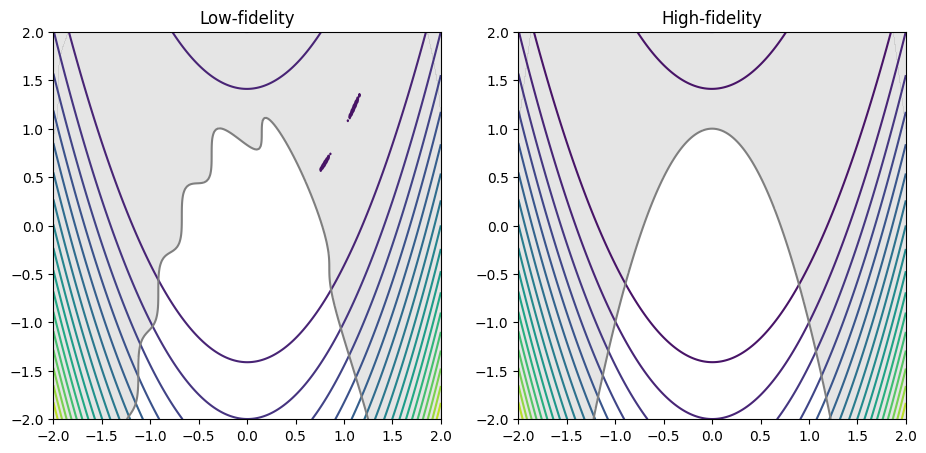

In [6]:
# defines the high-fidelity objective function
def rosenbrock_hf(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

# defines the low-fidelity objective function
def rosenbrock_lf(x):
    return rosenbrock_hf(x) + 0.1*np.sin(10*x[0] + 5*x[1])

# defines the high-fidelity constraint function
def constraint_hf(x):
    return -(-x[0]**2 - (x[1] - 1)**1/2)

# defines the low-fidelity constraint function
def constraint_lf(x):
    return constraint_hf(x) - 0.1*np.sin(10*x[0] + 5*x[1])

# defines the problem boundary
bounds = np.array([
    [-2, 2],
    [-2, 2]
])

# plots the low- and high-fidelity test problem
XX, YY, Z_hf = get_plot2d_data(rosenbrock_hf, bounds, 201)
_, _, Z_lf = get_plot2d_data(rosenbrock_lf, bounds, 201)
_, _, G_hf = get_plot2d_data(constraint_hf, bounds, 201)
_, _, G_lf = get_plot2d_data(constraint_lf, bounds, 201)

fig, ax = plt.subplots(1, 2, figsize=(11, 7))
ax[0].set_title("Low-fidelity")
ax[0].contour(XX, YY, Z_lf, levels=20)
ax[0].contourf(XX, YY, np.where(G_lf <= 0, np.nan, G_lf), levels=0, colors="C7", alpha=0.20)
ax[0].contour(XX, YY, G_lf, levels=[0], colors="C7")
ax[0].set_aspect("equal")

ax[1].set_title("High-fidelity")
ax[1].contour(XX, YY, Z_hf, levels=20)
ax[1].contourf(XX, YY, np.where(G_hf <= 0, np.nan, G_hf), levels=0, colors="C7", alpha=0.20)
ax[1].contour(XX, YY, G_hf, levels=[0], colors="C7")
ax[1].set_aspect("equal")

plt.show()


### Starting the optimization

The `minimize` method is called to begin the constrained multi-fidelity Bayesian optimization. Three arguments must be passed when dealing with constrained multi-fidelity optimization:

- `objective`: the function to minimize;
- `design_space`: the function boundary;
- `costs`: the sampling cost of each fidelity level;
- `constraints`: the constraint definitions.

<div class="admonition note"> <p class="admonition-title">Note</p>
    <p>The objective and the constraints callables, as well as the sampling costs must be ordered in increasing level of fidelity and must have the identical number of callables.<p>
</div>

Moreover, we can also pass the following optional arguments:

- `max_iter`: the maximum number of iterations before the program stops;
- `max_budget`: the maximum budget before the program stops. The budget is computed with the sampling costs;
- `driver_kwargs`: kwargs to pass to the optimization driver. The `seed` parameter makes this example reproducible;
- `strategy_kwargs`: kwargs to pass to the acquisition strategy.

<div class="admonition note"> <p class="admonition-title">Note</p>
    <p>The strategy_kwargs depend on the AcquisitionStrategy selected by the minimize method. For a multi-fidelity problem (constrained or unconstrained), the MFSEGO acquisition strategy is selected. The valid arguments can be consulted via the API reference.</p>
</div>

The minimize method returns a `State` object that contains the design of experiment (DoE) with all the low- and high-function samples. Using these samples, we can identify the best sampled function value found during the optimization process.


In [7]:
# defines the inequality constraint
constraint = [
    {
        "fun": [constraint_lf, constraint_hf],      # in increasing order of fidelity
        "upper": 0.,                                # equivalent to: g(x) <= 0
    }
]

state = minimize(
    [rosenbrock_lf, rosenbrock_hf],                 # in increasing order of fidelity
    bounds,
    costs=[0.2, 1.],
    constraints=constraint,
    max_iter=30,
    max_budget=15.,
    # arguments passed to the optimization driver
    driver_kwargs={
        "seed": 0
    },
    # arguments passed to the acquisition strategy
    strategy_kwargs={
        "fidelity_crit": "pessimistic",
        "sp_method": "Cobyla",
        "sp_tol": 1e-4
    }
)

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1          7.200    2.64887e+00      0.000e+00              1          0.804          1.917
             2          7.400    2.64887e+00      0.000e+00              1          0.761          1.434
             3          7.600    2.64887e+00      0.000e+00              1          0.699          1.485
             4          7.800    2.64887e+00      0.000e+00              1          0.760          1.383
             5          8.000    2.64887e+00      0.000e+00              1          0.702          2.299
             6          8.200    2.64887e+00      0.000e+00              1          0.756          2.276
             7          8.400    2.64887e+00      0.000e+00              1          0.696          2.596
             8          8.600    2.64887e+00      0.000e+00              1          0.719          2.708
             9          8.800    2.64887e+00      0.000

### Plotting the results

The code snippet below exports all the evaluated low- and high-fidelity design points, as well as their corresponding objective values, plotting them against their respective fidelity function. The best sample is marked with a star.

When exporting the dataset using the export_as_dict class method, use the `fidelity` array to distinguish between different fidelity levels, as demonstrated below.


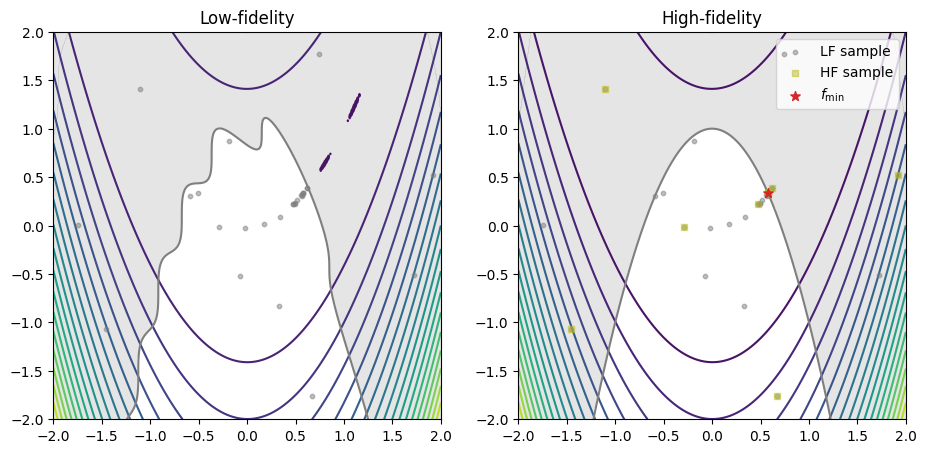

In [8]:
# gets the best sample (minimum feasible objective value)
best_sample = state.get_best_sample()

data = state.dataset.export_as_dict()

# retrieves the fidelity ID of each sample
fidelity = data["fidelity"].ravel()

# retrieves the low fidelity DoE
x_doe_lf = data["x"][fidelity == 0, :]
# y_doe_lf = data["obj"][fidelity == 0]

# retrieve the high fidelity DoE
x_doe_hf = data["x"][fidelity == 1, :]
# y_doe_hf = data["obj"][fidelity == 1]

fig, ax = plt.subplots(1, 2, figsize=(11, 7))
ax[0].set_title("Low-fidelity")
ax[0].contour(XX, YY, Z_lf, levels=20)
ax[0].contourf(XX, YY, np.where(G_lf <= 0, np.nan, G_lf), levels=0, colors="C7", alpha=0.2)
ax[0].contour(XX, YY, G_lf, levels=[0], colors="C7")
ax[0].set_aspect("equal")

ax[0].scatter(x_doe_lf[:, 0], x_doe_lf[:, 1], s=10, color="C7", alpha=0.5, label="LF sample", zorder=50)

ax[1].set_title("High-fidelity")
ax[1].contour(XX, YY, Z_hf, levels=20)
ax[1].contourf(XX, YY, np.where(G_hf <= 0, np.nan, G_hf), levels=0, colors="C7", alpha=0.2)
ax[1].contour(XX, YY, G_hf, levels=[0], colors="C7")
ax[1].set_aspect("equal")

# scatters the LF samples
ax[1].scatter(x_doe_lf[:, 0], x_doe_lf[:, 1], s=10, color="C7", alpha=0.5, label="LF sample", zorder=50)
# scatters the HF samples
ax[1].scatter(x_doe_hf[:, 0], x_doe_hf[:, 1], s=20, color="C8", alpha=0.5, marker="s", label="HF sample", zorder=60)
# plots the best sample
ax[1].scatter(best_sample.x[0], best_sample.x[1], s=50, color="C3", marker="*", label=r"$f_\min$", zorder=100)

ax[1].legend(loc="upper right")
plt.show()


## Many multi-fidelity levels optimization

The `minimize` method supports more than two fidelity levels. An example is coming soon.